# Tutorial 2 · Text Document Classification with Naive Bayes
## 按老师原任务，跑通新闻分类并解释结果

[先读 Lecture 2](Lecture02.md) · [Assignment 1 指南](Assignment01.md) · [运行说明](README.md)

主要来源：Tutorial2v2.ipynb（单元从原文件第一个开始计数，包括文字与代码）；dataAG.json。以下代码与解答为按原任务编写的参考实现。

老师的顺序是：认识AGNews → 建词向量 → Bernoulli NB → Multinomial NB → 看错分 → 改平滑/词表 → 实现Poisson NB。每步先解释要解决什么，再看代码与输出。默认从头运行全部代码，独立尝试题写在Markdown中，不影响运行。

**结果口径 / Result scope：** 本教程遵循课堂任务，多次查看同一份给定test的表现，用于练习与探索。它已参与模型/参数比较，不能被称为最终独立泛化估计。下方结果由代码计算，固定种子42。


## 学习地图 / Goal

| 原任务 | 优先级 | 难度与卡点 | 学到什么程度 | 对应讲义 |
|---|---|---|---|---|
| 数据与词向量 Tutorial2v2，第4–12个单元 | 核心必会 | 中：文档、词、矩阵轴 | 能建立固定词表并避免泄漏 | Lecture §12–13 |
| Bernoulli NB Tutorial2v2，第13–16个单元 | 核心必会 | 中：出现/未出现 | 会训练、计算指标、解释词概率 | §14–16 |
| Multinomial NB Tutorial2v2，第17–20个单元 | 核心必会 | 中：计数与TF-IDF | 会比较表示，解释参数含义 | §17–18 |
| 错分 Tutorial2v2，第21–24个单元 | 核心必会 | 中：观察不等于原因 | 会提出可核验解释 | §9、19 |
| 两种参数实验 Tutorial2v2，第25–28个单元 | 核心必会 | 中：受控比较 | 会画曲线、说明比较条件 | §13、15、17 |
| Poisson NB Tutorial2v2，第29–35个单元 | 核心必会 | 高：换CCD仍保留Bayes外框 | 会估计、算log分数并归一化 | §7；本文件§8 |
| 严格验证方案 | 常规掌握 | 中：开发与最终评估分开 | 能重画实验流程 | 方法补充，非改写原题 |

优先级依据当前任务。英文题意为忠实整理，中文解释补足必要条件；代码、类别名称和原文件名不翻译。


## 0. Setup｜只在这里改实验设置

在README所述独立环境中运行。先按[数据说明](../../docs/DATA.md)放置Canvas数据，仓库不附带数据集。AGNEWS_PATH默认读取仓库data目录下的对应文件，也可用COURSE_DATA_ROOT指定数据根目录。

**English:** Prepare the Canvas data using the data guide; datasets are not bundled. Configure parameters and the data path here, using data/ by default or COURSE_DATA_ROOT for another data root.

In [1]:
from pathlib import Path
import os
import json, hashlib, platform, importlib.metadata, textwrap, html
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import sparse
from scipy.special import gammaln, logsumexp
from scipy.stats import poisson
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from IPython.display import display, Markdown, HTML

REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p/'learning/course-notes-documents.json').is_file()), None)
if REPO is None:
    raise FileNotFoundError('Run this notebook from the CityU-StudyNotes checkout.')
COURSE = Path(os.environ.get('COURSE_DATA_ROOT', str(REPO/'data'))).expanduser().resolve()
NOTE_DIR = REPO/'CS5489/course-notes'
AGNEWS_PATH = COURSE/'CS5489/Lecture2/Tutorial2/dataAG.json'
if not AGNEWS_PATH.is_file():
    raise FileNotFoundError(f"Missing Canvas dataset; see docs/DATA.md and COURSE_DATA_ROOT: {AGNEWS_PATH}")

SEED = 42
DEFAULT_MAX_FEATURES = 1000
DEFAULT_ALPHA = 1.0
ALPHAS = [0.1, 0.3, 1.0, 3.0, 10.0]
VOCAB_LIMITS = [100, 500, 1000, 2000, 5000]
CATS = ["World", "Sports", "Business", "Sci/Tech"]
np.random.seed(SEED)
ASSET_DIR = NOTE_DIR / "assets"
ASSET_DIR.mkdir(exist_ok=True)
COLORS = ["#2870a2", "#b57319", "#698244", "#a74f72"]
plt.rcParams.update({"figure.figsize": (7.2, 4.2), "figure.dpi": 130, "font.size": 11,
                     "font.family": "DejaVu Sans", "axes.spines.top": False, "axes.spines.right": False})
def show_figure(fig, name):
    fig.savefig(ASSET_DIR / name, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

versions = {name: importlib.metadata.version(name) for name in
            ["numpy", "scipy", "scikit-learn", "matplotlib", "pandas", "nbformat"]}
print("Python:", platform.python_version(), "| seed:", SEED)
print("Package versions:", versions)
print("Data:", AGNEWS_PATH.name, "| SHA256:", hashlib.sha256(AGNEWS_PATH.read_bytes()).hexdigest())

Python: 3.12.14 | seed: 42
Package versions: {'numpy': '2.5.3', 'scipy': '1.18.1', 'scikit-learn': '1.9.1', 'matplotlib': '3.11.2', 'pandas': '3.0.6', 'nbformat': '5.11.1'}
Data: dataAG.json | SHA256: 6fc06494ec6a66501f4db2e0c9710e32db6c88a6a0ca8ff59db3620011fe378b



## 1. Load and inspect data｜先数清楚，再训练

**原任务 / Task（Tutorial2v2，第4–9个单元）：** 载入dataAG.json，检查训练/测试规模和四类标签，查看文本。  
**English:** Load dataAG.json, inspect split sizes and class counts, and examine the text records.

一条字典是一篇新闻，text是字符串、label是0到3的已有标签。下面仅显示各类计数和一条截短样本，完整数据留在原文件。Tutorial2v2，第6个单元写2034/1353，但本次给定文件实际为2000/1000；以读到的文件为准，差异明确保留。

In [2]:
data = json.loads(AGNEWS_PATH.read_text(encoding="utf-8"))
assert set(data) == {"train", "test"}
for split, rows in data.items():
    assert rows and all(isinstance(r["text"], str) and isinstance(r["label"], int) for r in rows)
    assert all(r["label"] in range(4) for r in rows)
    assert all(r["text"].strip() for r in rows)
assert (len(data["train"]), len(data["test"])) == (2000, 1000), "Dataset differs from the reviewed snapshot."

train_text = [r["text"] for r in data["train"]]
test_text = [r["text"] for r in data["test"]]
train_y = np.array([r["label"] for r in data["train"]])
test_y = np.array([r["label"] for r in data["test"]])
class_counts = pd.DataFrame({
    "Class": CATS,
    "Train documents": [int((train_y == c).sum()) for c in range(4)],
    "Test documents": [int((test_y == c).sum()) for c in range(4)],
})
assert set(np.unique(train_y)) == set(range(4)) and set(np.unique(test_y)) == set(range(4))
display(class_counts)
print("One training example:", CATS[train_y[0]])
print(textwrap.fill(train_text[0][:280], width=88))
print("Blank text rows:", sum(not t.strip() for t in train_text + test_text))

,Class,Train documents,Test documents
0,World,511,262
1,Sports,493,261
2,Business,512,249
3,Sci/Tech,484,228


One training example: World
Three UK soldiers killed in central Iraq Three British troops have been killed and
others injured in an attack in central Iraq, British Armed Forces Minister Adam Ingram
confirmed on Thursday.
Blank text rows: 0


**怎样检查 / Check：** 两个计数列分别加到2000和1000；标签与四个英文名称按原顺序对应。保留文件给定的训练／测试划分。

**独立检查题：** 2000篇新闻、实际词表1000词，特征矩阵和标签数组各是什么形状？  
**English question:** For 2000 documents and an actual vocabulary of 1000 terms, what are the shapes of the feature matrix and label array?  
**答案：** X为(2000,1000)，y为(2000,)；每篇文档一行，每个词一列。若1000只是词表上限，实际列数仍应读取vectorizer。  
**English answer:** X has shape (2000,1000) and y has shape (2000,). Documents are rows and vocabulary terms are columns. If 1000 is only a requested cap, inspect the fitted vocabulary for the actual column count.


## 2. Build document vectors｜把词表当成一把固定的尺子

**原任务 / Task（Tutorial2v2，第10–12个单元）：** 从训练文本建词表，再转换两份数据，自己选择词表大小。  
**English:** Build a vocabulary from training documents and transform both splits using that vocabulary.

默认最多1000词，沿课堂例子使用英文停用词、默认小写化。fit_transform只作用于train；test只transform。test中独有的词会被忽略。下面先保留原始整数计数：Bernoulli会二值化，Poisson也需要这些计数；不要稍后用TF-IDF覆盖count_train这个变量。

In [3]:
vectorizer = CountVectorizer(stop_words="english", max_features=DEFAULT_MAX_FEATURES)
count_train = vectorizer.fit_transform(train_text)
count_test = vectorizer.transform(test_text)
feature_names = vectorizer.get_feature_names_out()
assert count_train.shape == (len(train_text), len(feature_names))
assert count_test.shape == (len(test_text), len(feature_names))
assert np.isfinite(count_train.data).all() and (count_train.data >= 0).all()
print("Train / test shapes:", count_train.shape, count_test.shape)
print("Requested / actual vocabulary:", DEFAULT_MAX_FEATURES, len(feature_names))
zero_train = int((np.asarray(count_train.sum(axis=1)).ravel() == 0).sum())
zero_test = int((np.asarray(count_test.sum(axis=1)).ravel() == 0).sum())
print("All-zero feature rows, train / test:", zero_train, zero_test)
row = count_train.getrow(0)
display(pd.DataFrame({"Word": feature_names[row.indices], "Count": row.data})
        .sort_values(["Count", "Word"], ascending=[False, True]).head(8))

# Tiny independent check: do not learn the held-out-only term.
probe = CountVectorizer().fit(["trainword common", "another common"])
before = dict(probe.vocabulary_)
probe.transform(["heldoutonly common"])
assert probe.vocabulary_ == before and "heldoutonly" not in probe.vocabulary_

Train / test shapes: (2000, 1000) (1000, 1000)
Requested / actual vocabulary: 1000 1000
All-zero feature rows, train / test: 2 2


,Word,Count
5,british,2
3,central,2
4,iraq,2
2,killed,2
9,armed,1
8,attack,1
12,confirmed,1
10,forces,1


**怎样读 / Interpretation：** 稀疏表示省略存储零元素，未出现这个事实仍由模型处理。停用词和词表截断之后，原文非空也可能得到全零行；这不等于读取失败。

**常见错误 / Pitfall：** 对test重新fit会使坐标改变并引入泄漏。把训练列名贴到一个独立拟合的test矩阵上，不会修复这个问题。  
**English takeaway:** The vocabulary is learned from training text and then held fixed. A zero vector after preprocessing can be a legitimate representation outcome.


## 3. Bernoulli Naive Bayes｜先问有没有，不问重复几次

**原任务 / Task（Tutorial2v2，第13–16个单元）：** 训练Bernoulli NB、报告测试accuracy，并查看每类高概率词。  
**English:** Train Bernoulli NB, report test accuracy and inspect high-probability words for each class.

用alpha=1作本次默认值；这不是老师规定的最优参数。BernoulliNB的binarize=0.0把正计数变成1。其文档得分同时考虑出现与未出现；先回看[Lecture §14–15](Lecture02.md#bernoulli)中的手算，理解为什么分母是$N_c+2\alpha$。

In [4]:
bnb = BernoulliNB(alpha=DEFAULT_ALPHA, binarize=0.0).fit(count_train, train_y)
pred_bnb = bnb.predict(count_test)
prob_bnb = bnb.predict_proba(count_test)
assert np.allclose(prob_bnb.sum(axis=1), 1)
bnb_acc = float(accuracy_score(test_y, pred_bnb))
print(f"Bernoulli NB: {int((pred_bnb == test_y).sum())}/{len(test_y)} correct; accuracy={bnb_acc:.3%}")
print("Model class order:", bnb.classes_)
print("One posterior vector:", np.round(prob_bnb[0], 4))

def show_top_words(model, names, title):
    rows = []
    for i, label in enumerate(model.classes_):
        ids = np.argsort(-model.feature_log_prob_[i], kind="stable")[:10]
        for rank, j in enumerate(ids, 1):
            rows.append({"Class": CATS[int(label)], "Rank": rank,
                         "Word": names[j], "Log parameter": round(float(model.feature_log_prob_[i, j]), 4)})
    table = pd.DataFrame(rows)
    display(HTML("<details><summary>" + html.escape(title) +
                 "</summary>" + table.to_html(index=False, escape=True) + "</details>"))
    return table

bnb_words = show_top_words(bnb, feature_names, "Top 10 per class / 展开各类前10词（Bernoulli）")

Bernoulli NB: 821/1000 correct; accuracy=82.100%
Model class order: [0 1 2 3]
One posterior vector: [4.800e-03 9.817e-01 1.000e-04 1.340e-02]


Class,Rank,Word,Log parameter
World,1,said,-1.3882
World,2,39,-1.6452
World,3,reuters,-1.8836
World,4,iraq,-2.1131
World,5,killed,-2.2149
World,6,minister,-2.2149
World,7,president,-2.2149
World,8,ap,-2.3485
World,9,wednesday,-2.4116
World,10,people,-2.4336


**解释 / Interpretation：** 每行的概率参数是“该类文档含这个词”的概率，这个排序反映类内出现率。几类都常见的词可能排得很前，却不擅长区分类别。

**自查：** 同一文档中market从1次变10次，保持已训练模型、词表和其他词不变，这个Bernoulli预测会改变吗？  
**English question:** In one document, change the count of market from 1 to 10 while keeping the fitted model, vocabulary and other word counts fixed. Does this Bernoulli prediction change?  
**答案：** 不会，二值化后输入相同。  
**English answer:** No. The binary presence vector stays the same.

<a id="31-bernoulli-parameter-comparisont13"></a>

### 3.1 Bernoulli parameter comparison｜比较平滑与词表规模

老师还要求尝试alpha和max_features。保持同一数据划分：第一组固定词表上限1000，只改alpha；第二组固定alpha=1，只改词表上限。分别观察平滑与表示规模怎样影响结果。

来源：Tutorial2v2，第13个单元。

**English:** Vary alpha with a fixed 1000-word cap, then vary the vocabulary cap with alpha fixed at 1. Fit each vocabulary on training text only. These are two separate one-factor sweeps.

In [5]:
bnb_parameter_rows = []
for alpha in ALPHAS:
    fitted = BernoulliNB(alpha=alpha, binarize=0.0).fit(count_train, train_y)
    bnb_parameter_rows.append({"Vary": "alpha", "Alpha": alpha,
        "Requested vocabulary": DEFAULT_MAX_FEATURES, "Actual vocabulary": count_train.shape[1],
        "Classroom test accuracy": accuracy_score(test_y, fitted.predict(count_test))})
for limit in VOCAB_LIMITS:
    vec = CountVectorizer(stop_words="english", max_features=limit)
    fit_counts = vec.fit_transform(train_text)
    eval_counts = vec.transform(test_text)
    fitted = BernoulliNB(alpha=DEFAULT_ALPHA, binarize=0.0).fit(fit_counts, train_y)
    bnb_parameter_rows.append({"Vary": "vocabulary", "Alpha": DEFAULT_ALPHA,
        "Requested vocabulary": limit, "Actual vocabulary": fit_counts.shape[1],
        "Classroom test accuracy": accuracy_score(test_y, fitted.predict(eval_counts))})
bnb_parameter_table = pd.DataFrame(bnb_parameter_rows)
display(bnb_parameter_table)
base_rows = bnb_parameter_table[(bnb_parameter_table["Alpha"] == DEFAULT_ALPHA) &
    (bnb_parameter_table["Requested vocabulary"] == DEFAULT_MAX_FEATURES)]
assert np.allclose(base_rows["Classroom test accuracy"], bnb_acc)
print("Best tested settings within each one-factor sweep (classroom exploration):")
for varied, group in bnb_parameter_table.groupby("Vary", sort=False):
    display(group[np.isclose(group["Classroom test accuracy"], group["Classroom test accuracy"].max())])

,Vary,Alpha,Requested vocabulary,Actual vocabulary,Classroom test accuracy
0,alpha,0.1,1000,1000,0.822
1,alpha,0.3,1000,1000,0.825
2,alpha,1.0,1000,1000,0.821
3,alpha,3.0,1000,1000,0.808
4,alpha,10.0,1000,1000,0.776
5,vocabulary,1.0,100,100,0.684
6,vocabulary,1.0,500,500,0.780
7,vocabulary,1.0,1000,1000,0.821
8,vocabulary,1.0,2000,2000,0.842
9,vocabulary,1.0,5000,5000,0.856


Best tested settings within each one-factor sweep (classroom exploration):


,Vary,Alpha,Requested vocabulary,Actual vocabulary,Classroom test accuracy
1,alpha,0.3,1000,1000,0.825


,Vary,Alpha,Requested vocabulary,Actual vocabulary,Classroom test accuracy
9,vocabulary,1.0,5000,5000,0.856


**如何解释 / Interpretation：** 在Vary=alpha的行内比较平滑，再在Vary=vocabulary的行内比较词表规模。同时查看实际词表列：上限不一定就是最终词数。默认设置在两组中重复出现，用来核对两条流程是否一致，不算两次独立实验。

**English:** Compare settings within each sweep and report the actual vocabulary size. The repeated default setting checks consistency between the two paths.


## 4. Multinomial Naive Bayes model｜让非负权重进入另一个模型

**原任务 / Task（Tutorial2v2，第17–20个单元）：** 使用TF-IDF表示训练Multinomial NB，比较表现，并查看各类高权重词。  
**English:** Train Multinomial NB on TF-IDF features, compare accuracy, and inspect the learned word parameters.

沿Lecture2b cell91设置norm="l1"，并显式保留默认smooth_idf=True。IDF只从train拟合。非零文档变换后各项和为1；全零文档仍为0。TF-IDF是非负分数权重，不是Poisson整数计数，也不应硬套阶乘形式的整数多项式PMF。

此处从Bernoulli/count换到Multinomial/TF-IDF，**同时改变了模型与表示**。可以比较两条完整流程，但不能把差异全归因于“分类器更好”。相关数学见[Lecture §17–18](Lecture02.md#tfidf)。

In [6]:
tfidf = TfidfTransformer(use_idf=True, norm="l1", smooth_idf=True)
tf_train = tfidf.fit_transform(count_train)
idf_before_test = tfidf.idf_.copy()
tf_test = tfidf.transform(count_test)
assert np.array_equal(tfidf.idf_, idf_before_test)
sums = np.asarray(tf_train.sum(axis=1)).ravel()
assert np.all(np.isclose(sums, 0) | np.isclose(sums, 1))
mnb = MultinomialNB(alpha=DEFAULT_ALPHA).fit(tf_train, train_y)
pred_mnb = mnb.predict(tf_test)
mnb_acc = float(accuracy_score(test_y, pred_mnb))
assert np.allclose(mnb.predict_proba(tf_test).sum(axis=1), 1)
print(f"Multinomial NB + TF-IDF: {int((pred_mnb == test_y).sum())}/{len(test_y)} correct; accuracy={mnb_acc:.3%}")
print("Bernoulli difference (percentage points):", round((mnb_acc-bnb_acc)*100, 2))
mnb_words = show_top_words(mnb, feature_names, "Top 10 per class / 展开各类前10词（Multinomial / TF-IDF）")

Multinomial NB + TF-IDF: 821/1000 correct; accuracy=82.100%
Bernoulli difference (percentage points): 0.0


Class,Rank,Word,Log parameter
World,1,iraq,-5.3403
World,2,39,-5.4974
World,3,ap,-5.5248
World,4,said,-5.5487
World,5,reuters,-5.6197
World,6,killed,-5.6701
World,7,president,-5.6862
World,8,minister,-5.7645
World,9,troops,-5.8280
World,10,baghdad,-5.8374


**检查 / Check：** Multinomial各词参数在每个类别内和为1；Bernoulli每词是一个独立二元试验，其出现率无需跨词相加为1。这里输入是TF-IDF，高参数值说明该词在同类文档中累积的TF-IDF权重较大；这些小数权重与原始出现次数不同。

**English takeaway:** The comparison is between complete representation–model pipelines. TF-IDF must reuse training IDF, and fractional weights are a practical model input rather than literal integer counts.

In [7]:
assert np.allclose(np.exp(mnb.feature_log_prob_).sum(axis=1), 1)
print("Multinomial parameter row sums:", np.exp(mnb.feature_log_prob_).sum(axis=1))
print("Bernoulli presence-probability sums (not constrained to one):",
      np.round(np.exp(bnb.feature_log_prob_).sum(axis=1), 2))

Multinomial parameter row sums: [1. 1. 1. 1.]
Bernoulli presence-probability sums (not constrained to one): [13.29 11.79 15.05 12.74]



## 5. Misclassified documents｜分错了什么？哪些解释只是猜想？

**原任务 / Task（Tutorial2v2，第21–24个单元）：** 查看错分新闻，并给出可能的原因。  
**English:** Inspect misclassified documents and suggest plausible reasons.

先看混淆矩阵：行是真实类别，列是预测类别，每行总数应等于该类test文档数。再看MNB流程前3条错分，记录索引、真值、预测、短文本和模型后验。错误类别可能语义接近、文本包含多类词、关键词被截断、表示丢失关系，或者标签本身值得核查；这些都要由具体证据支持。

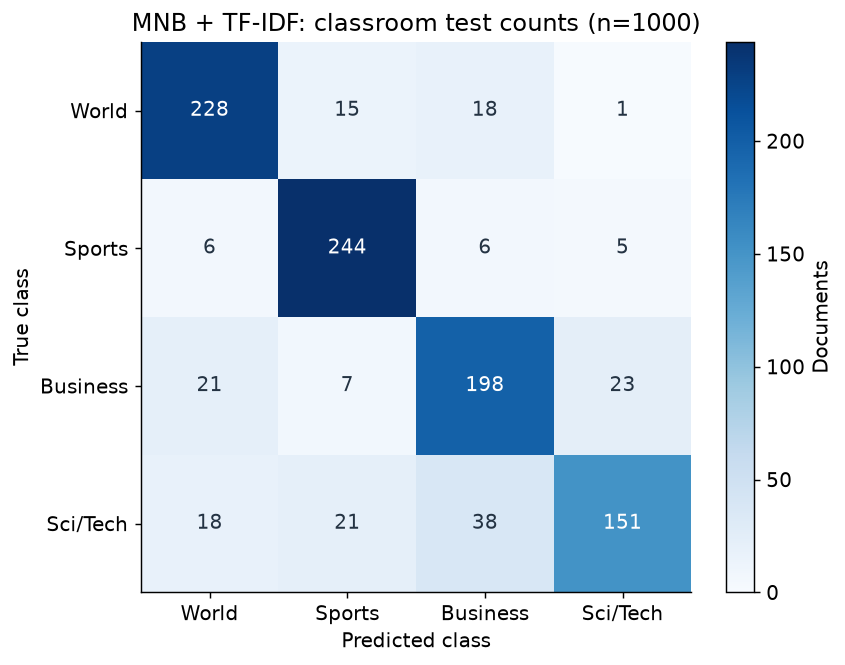


Index=1 | true=Business | predicted=World
Hurricane loss 'less than feared' Hurricane Frances could cause \$3-6bn in insured losses
in the US, less than experts first predicted.
Class posteriors: {'World': 0.2879, 'Sports': 0.2345, 'Business': 0.2716, 'Sci/Tech': 0.2061}
Retained nonzero features: 4
Retained words: experts, hurricane, loss, losses

Index=3 | true=World | predicted=Business
Consumer Confidence Dips in September NEW YORK - Job worries helped push consumer
confidence down in September for the second consecutive month, a New York-based private
research group said Tuesday.    The Consumer Confidence Index fell 1.9 points to 96.8 from
a revised reading of 98.7 in August, according to The Conference Board...
Class posteriors: {'World': 0.2177, 'Sports': 0.2179, 'Business': 0.312, 'Sci/Tech': 0.2524}
Retained nonzero features: 22
Retained words: according, august, based, board, conference, consumer, fell, group, helped, job, month, new, points, private, push, research, said, 

In [8]:
cm = confusion_matrix(test_y, pred_mnb, labels=np.arange(4))
assert cm.sum() == len(test_y)
assert np.array_equal(cm.sum(axis=1), np.bincount(test_y, minlength=4))
fig, ax = plt.subplots(figsize=(6.5, 5.0), layout="constrained")
im = ax.imshow(cm, cmap="Blues", vmin=0)
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "#243343")
ax.set(xticks=range(4), yticks=range(4), xticklabels=CATS, yticklabels=CATS,
       xlabel="Predicted class", ylabel="True class",
       title=f"MNB + TF-IDF: classroom test counts (n={len(test_y)})")
fig.colorbar(im, ax=ax, label="Documents")
show_figure(fig, "tutorial-confusion.png")

error_indices = np.flatnonzero(pred_mnb != test_y)[:3]
for idx in error_indices:
    print(f"\nIndex={idx} | true={CATS[test_y[idx]]} | predicted={CATS[pred_mnb[idx]]}")
    print(textwrap.fill(test_text[idx][:350], 90))
    print("Class posteriors:", dict(zip(CATS, [float(v) for v in np.round(mnb.predict_proba(tf_test[idx])[0], 4)])))
    print("Retained nonzero features:", count_test[idx].nnz)
    print("Retained words:", ", ".join(feature_names[count_test[idx].indices]))
if len(error_indices) == 0:
    print("No misclassifications in this run; do not manufacture error examples.")

**怎样写答案 / How to explain:** “这条新闻被预测为Business，我在原文看到商业词汇”是观察；“如果保留某个短语就一定能修正”是待验证假设。可以先查词表是否保留该词，再用只改变表示的对照实验检验解释。

把错分按真实类别和预测类别分组，看看模型主要混淆了哪些主题。如何为正式评价另留数据，见§9。

**English takeaway:** Describe the observed error first, then separate plausible explanations from verified causes. Group errors by true and predicted class to identify recurring confusions.

**本次固定样本的读法 / Reading the current examples：**
- Index 1描述飓风造成的保险损失，原标签Business、预测World，仅保留4个词。灾害事件与经济损失共用同一短文，可以提出“主题边界与词表截断影响判断”的假设；尚未用受控实验验证。
- Index 3讨论消费者信心和就业，原标签World、预测Business。经济主题词使这个预测值得理解，但不能只凭主题印象把原标签改掉。
- Index 14讨论太阳帆航天器及项目资助，原标签Sci/Tech、预测Business；两个模型后验接近。查看保留词可以帮助区分表示损失、主题重叠和模型限制这几种解释。

English: Index 1 combines disaster and insurance-loss language; index 3 discusses economic confidence despite its World label; index 14 combines a spacecraft project and funding. These observations suggest explanations to test; retain the supplied evaluation labels. The retained-word output lets you inspect the representation.


## 6. Effect of smoothing｜只改alpha，画一条能解释的曲线

**原任务 / Task（Tutorial2v2，第25–26个单元）：** 用Multinomial TF-IDF模型画accuracy随alpha变化，并找本次网格中的最好值。  
**English:** Plot Multinomial TF-IDF accuracy against alpha and identify the best tested setting.

固定划分、词表和TF-IDF变换，仅改变alpha。横轴使用对数刻度，因为候选跨了两个数量级；纵轴为accuracy。表里同时保留训练表现，帮助检查拟合与测试不一定同步。记录候选范围和对应最高点，便于复查曲线。

,alpha,Train accuracy,Classroom test accuracy
0,0.1,0.9120,0.817
1,0.3,0.9035,0.821
2,1.0,0.8930,0.821
3,3.0,0.8720,0.807
4,10.0,0.7845,0.729


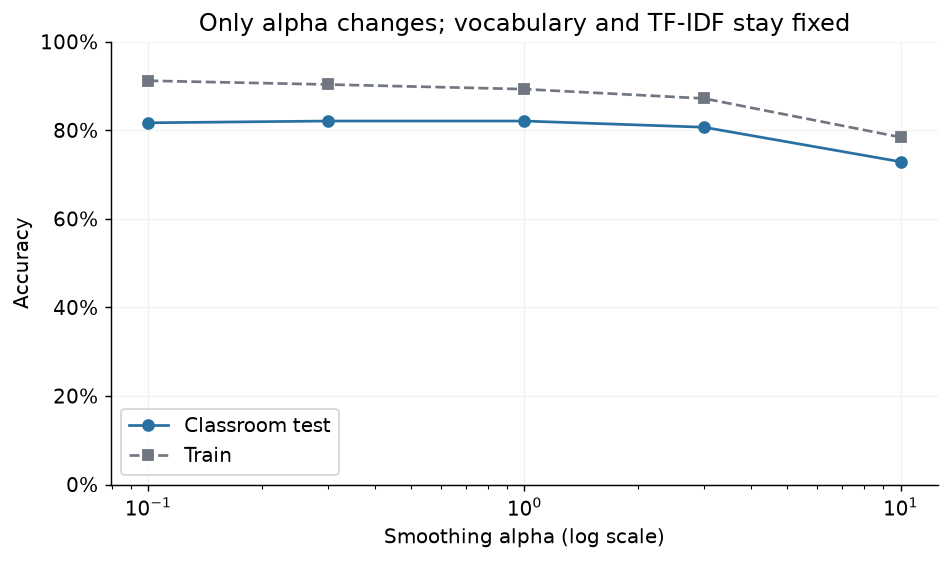

Best tested alpha (first/smallest on ties): 0.3 | classroom test: 82.100%


In [9]:
alpha_rows = []
for alpha in ALPHAS:
    fitted = MultinomialNB(alpha=alpha).fit(tf_train, train_y)
    alpha_rows.append({"alpha": alpha,
                       "Train accuracy": float(accuracy_score(train_y, fitted.predict(tf_train))),
                       "Classroom test accuracy": float(accuracy_score(test_y, fitted.predict(tf_test)))})
alpha_table = pd.DataFrame(alpha_rows)
display(alpha_table)
best_alpha_row = alpha_table.loc[alpha_table["Classroom test accuracy"].idxmax()]
best_alpha = float(best_alpha_row["alpha"])
fig, ax = plt.subplots(layout="constrained")
ax.plot(alpha_table["alpha"], alpha_table["Classroom test accuracy"], marker="o",
        color=COLORS[0], label="Classroom test")
ax.plot(alpha_table["alpha"], alpha_table["Train accuracy"], marker="s",
        color="#707780", linestyle="--", label="Train")
ax.set(xscale="log", ylim=(0,1), xlabel="Smoothing alpha (log scale)", ylabel="Accuracy",
       title="Only alpha changes; vocabulary and TF-IDF stay fixed")
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(alpha=.15); ax.legend()
show_figure(fig, "tutorial-alpha.png")
print("Best tested alpha (first/smallest on ties):", best_alpha,
      "| classroom test:", f'{best_alpha_row["Classroom test accuracy"]:.3%}')

**自查：** 在其他设置固定时，alpha越大，测试accuracy是否一定越高？  
**English question:** With other settings fixed, must a larger alpha produce higher test accuracy?  
**答案：** 不一定。平滑缓解稀疏估计，但过强时可能抹平类别差异；本次曲线的形状要由实际输出回答。  
**English answer:** No. Smoothing stabilizes sparse estimates, but excessive smoothing can suppress useful class differences. Describe the measured curve rather than assuming a monotonic improvement.


## 7. Effect of vocabulary size｜更多词，真的提供更多有效证据吗？

**原任务 / Task（Tutorial2v2，第27–28个单元）：** 画accuracy随词表上限变化，并找当前网格中的最好值。  
**English:** Plot accuracy against vocabulary limit and identify the best tested limit.

为单独观察词表，这一组将alpha固定为默认1，**不继承上一组用test挑出的best_alpha**。每个上限都仅从train重建词表与IDF，再应用到test。请求上限和实际大小一起报告；各词表坐标不同，因此每次都要重新拟合模型。

,Requested limit,Actual vocabulary,Train accuracy,Classroom test accuracy
0,100,100,0.6995,0.686
1,500,500,0.8575,0.796
2,1000,1000,0.8930,0.821
3,2000,2000,0.9165,0.821
4,5000,5000,0.9305,0.823


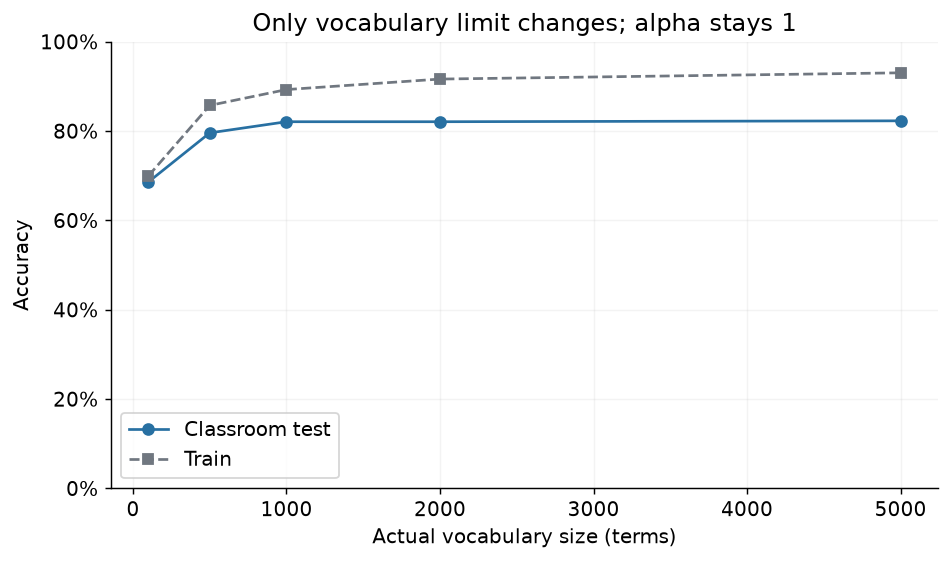

Best tested limit: 5000 | actual size: 5000 | classroom test: 82.300%


In [10]:
vocab_rows = []
for limit in VOCAB_LIMITS:
    vec = CountVectorizer(stop_words="english", max_features=limit)
    counts_fit = vec.fit_transform(train_text)
    counts_eval = vec.transform(test_text)
    transformer = TfidfTransformer(norm="l1", use_idf=True, smooth_idf=True)
    z_fit = transformer.fit_transform(counts_fit)
    z_eval = transformer.transform(counts_eval)
    fitted = MultinomialNB(alpha=DEFAULT_ALPHA).fit(z_fit, train_y)
    vocab_rows.append({"Requested limit": limit, "Actual vocabulary": counts_fit.shape[1],
                       "Train accuracy": float(accuracy_score(train_y, fitted.predict(z_fit))),
                       "Classroom test accuracy": float(accuracy_score(test_y, fitted.predict(z_eval)))})
vocab_table = pd.DataFrame(vocab_rows)
display(vocab_table)
best_vocab_row = vocab_table.loc[vocab_table["Classroom test accuracy"].idxmax()]
fig, ax = plt.subplots(layout="constrained")
ax.plot(vocab_table["Actual vocabulary"], vocab_table["Classroom test accuracy"], marker="o",
        color=COLORS[0], label="Classroom test")
ax.plot(vocab_table["Actual vocabulary"], vocab_table["Train accuracy"], marker="s",
        color="#707780", linestyle="--", label="Train")
ax.set(ylim=(0,1), xlabel="Actual vocabulary size (terms)", ylabel="Accuracy",
       title="Only vocabulary limit changes; alpha stays 1")
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(alpha=.15); ax.legend()
show_figure(fig, "tutorial-vocabulary.png")
print("Best tested limit:", int(best_vocab_row["Requested limit"]),
      "| actual size:", int(best_vocab_row["Actual vocabulary"]),
      "| classroom test:", f'{best_vocab_row["Classroom test accuracy"]:.3%}')

**怎样读曲线 / Reading the curve:** 增加词表可能保留更多主题线索，也会引入稀有词。结合实际词数观察准确率是上升、持平还是下降，并与默认1000词的结果比较。这一组固定alpha，因此两条曲线分别展示单因素变化，没有测试所有alpha与词表上限的组合。

**English:** Compare each point with the default 1000-word cap and inspect the actual vocabulary size. Alpha is fixed here; the two curves do not form a joint parameter search.


## 8. Poisson Naive Bayes｜外框不变，换掉词计数的分布

**原任务 / Task（Tutorial2v2，第29–35个单元）：** 用Poisson分布建模每类、每词的计数，按老师给的接口实现分类器，再与前两种流程比较。  
**English:** Implement Poisson NB for raw word counts using the provided class interface, then compare it with the previous pipelines.

### 8.1 参数估计与log分数

给定类别c，特征$x_j$是每篇文档中词j的**非负整数计数**。模型把一篇文档作为一次计数观察，估计“这个词在该类的一篇文档里平均出现几次”：

$$p(x_j\mid c)=e^{-\mu_{j,c}}\frac{\mu_{j,c}^{x_j}}{x_j!},
\qquad
\hat\mu^{MLE}_{j,c}=\frac{T_{j,c}}{N_c}.$$

$T_{j,c}$是该类所有文档的词j计数之和；$N_c$是该类文档数。这里$\mu$不要求跨词和为1，分母不是全类的总词数。这里没有按各篇文档长度单独调整平均次数；如果文章长短差别很大，这个假设可能不合适。

对正率求导可得到MLE：与$\mu$有关的log似然是$T\log\mu-N_c\mu$，导数$T/\mu-N_c=0$。T=0时最大值在边界$\mu=0$，不是除以零得到的内点解。

各词在给定类别下的对数概率相加，得到整篇文档的对数似然：

$$\log p(\mathbf{x}\mid c)=
\sum_j[x_j\log\mu_{j,c}-\mu_{j,c}-\log(x_j!)].
$$

加上类别的对数先验$\log p(c)$后，便可比较各类得分；需要后验概率时，再用[Lecture §7](Lecture02.md#log-scores)的logsumexp归一化。阶乘项对同一文档的所有类相同，选类别时可消去；参考实现保留它，以便与scipy的logpmf逐项校验。

### 8.2 模板未定义的alpha：明确采用一个补充约定

分类器接口提供了alpha参数，但教师模板没有指定平滑公式（Tutorial2v2，第32个单元）。这里对alpha>0明确选用：

$$\hat\mu_{j,c}=\frac{T_{j,c}+\alpha}{N_c+\alpha}.$$

分子在观察到的总次数上加alpha，分母在文档数上也加alpha。可以先把它理解成加入一份“平均每篇出现1次”的先验信息，alpha控制这份信息的权重。本实现将alpha=0定义为不平滑。

<details markdown="1"><summary>选读：这个平滑公式的概率依据</summary>

当alpha>0，给每个率使用Gamma(shape=alpha, rate=alpha)先验，观察数据后取后验均值，就得到上式。它是本参考实现明确选用的补充约定，教师模板只提供alpha接口，没有指定该公式。后验均值与MAP是不同估计；alpha=0采用MLE分支，不解释为Gamma(0,0)先验。

</details>

**教学手算 / Worked:** 某词在同类4篇文档计数[0,0,0,0]。MLE=0；alpha=1时，按上述约定，后验均值=(0+1)/(4+1)=0.2。  
**English worked example:** A word has counts [0,0,0,0] in four same-class documents. Its MLE rate is 0; with alpha=1, the specified posterior-mean rate is (0+1)/(4+1)=0.2. The zero MLE would assign zero probability to every positive future count.

**你来试：** 同类4篇计数[0,1,0,3]，alpha=1，按上述约定求MLE与平滑率。  
**English question:** A word has counts [0,1,0,3] in four same-class documents. With alpha=1 and the convention above, find its MLE rate and smoothed rate.  
**答案：** MLE=4/4=1；平滑率=5/5=1。两个值恰好相同，不代表平滑不起作用于其他数据；先验均值在此也是1。  
**English answer:** The MLE rate is 4/4=1 and the smoothed rate is 5/5=1. They coincide because the observed mean equals the prior mean; smoothing can still change estimates for other data.

In [11]:
class PoissonNB:
    # Poisson counts with explicit Gamma(alpha, alpha) posterior-mean smoothing.
    def __init__(self, alpha=1.0):
        if not np.isfinite(alpha) or alpha < 0:
            raise ValueError("alpha must be finite and nonnegative")
        self.alpha = float(alpha)

    def _counts(self, X, fitting=False):
        X = sparse.csr_matrix(X, dtype=float)
        if X.ndim != 2 or X.shape[1] == 0:
            raise ValueError("X must have sample rows and at least one feature")
        if not np.isfinite(X.data).all() or (X.data < 0).any():
            raise ValueError("Poisson features must be finite nonnegative counts")
        if not np.allclose(X.data, np.round(X.data), rtol=0, atol=1e-10):
            raise ValueError("Poisson requires integer counts, not TF-IDF")
        if not fitting and X.shape[1] != self.n_features_in_:
            raise ValueError("Feature count differs from fitted vocabulary")
        return X

    def fit(self, X, y):
        X = self._counts(X, fitting=True)
        y = np.asarray(y)
        if y.ndim != 1 or len(y) != X.shape[0] or len(y) == 0:
            raise ValueError("y must have one label per nonempty training row")
        self.classes_, class_counts = np.unique(y, return_counts=True)
        self.n_features_in_ = X.shape[1]
        self.class_prior_ = class_counts / len(y)
        self.rate_ = np.vstack([
            (np.asarray(X[y == label].sum(axis=0)).ravel() + self.alpha) / (n + self.alpha)
            for label, n in zip(self.classes_, class_counts)
        ])
        return self

    def compute_logccd(self, X, c):
        # c is a class-column index; actual labels are stored in classes_.
        X = self._counts(X)
        rate = self.rate_[c]
        positive = rate > 0
        safe_log_rate = np.zeros_like(rate)
        safe_log_rate[positive] = np.log(rate[positive])
        factorial = X.copy()
        factorial.data = gammaln(factorial.data + 1)
        scores = (np.asarray(X @ safe_log_rate).ravel()
                  - rate.sum() - np.asarray(factorial.sum(axis=1)).ravel())
        # Handle Poisson(0) exactly: P(0)=1, P(positive count)=0.
        impossible = np.asarray(X[:, ~positive].sum(axis=1)).ravel() > 0
        scores[impossible] = -np.inf
        return scores

    def compute_logjoint(self, X):
        return np.column_stack([
            self.compute_logccd(X, c) + np.log(self.class_prior_[c])
            for c in range(len(self.classes_))
        ])

    @staticmethod
    def _require_possible(scores):
        bad = np.flatnonzero(~np.isfinite(scores).any(axis=1))
        if len(bad):
            raise ValueError(f"All classes give zero likelihood for rows {bad[:8].tolist()}; "
                             "use an explicitly justified positive smoothing or revise the model.")

    def predict_logproba(self, X):
        scores = self.compute_logjoint(X)
        self._require_possible(scores)
        return scores - logsumexp(scores, axis=1, keepdims=True)

    def predict_proba(self, X):
        return np.exp(self.predict_logproba(X))

    def predict(self, X):
        scores = self.compute_logjoint(X)
        self._require_possible(scores)
        return self.classes_[scores.argmax(axis=1)]

### 8.3 先用四条小数据检查，再跑整份新闻

训练计数为[[1,0],[3,2],[0,2],[0,4]]，前两条是类10、后两条是类20。alpha=1时，两类率应为[5/3,1]和[1/3,7/3]，先验各0.5。本实现用classes_保存真实标签，避免原骨架“标签必须从0连续编号”的隐含限制；AGNews的0–3标签不因此改变。

**English:** Check the fitted rates, likelihoods and normalization on a tiny known example before trusting dataset-level accuracy. Nonconsecutive labels test the label mapping separately.

In [12]:
toy_X = np.array([[1,0], [3,2], [0,2], [0,4]])
toy_y = np.array([10,10,20,20])
toy = PoissonNB(alpha=1).fit(toy_X, toy_y)
np.testing.assert_allclose(toy.rate_, [[5/3,1], [1/3,7/3]])
np.testing.assert_allclose(toy.class_prior_, [.5,.5])
queries = np.array([[1,0], [0,2], [0,0]])
expected_joint = np.column_stack([
    poisson.logpmf(queries, mu=toy.rate_[c]).sum(axis=1) + np.log(.5)
    for c in range(2)
])
np.testing.assert_allclose(toy.compute_logjoint(queries), expected_joint)
np.testing.assert_allclose(toy.predict_proba(queries).sum(axis=1), 1)
assert set(toy.predict(queries)) <= {10,20}

mle = PoissonNB(alpha=0).fit(toy_X, toy_y)
assert np.isneginf(mle.compute_logccd([[1,0]], 1)[0])
np.testing.assert_allclose(mle.predict_proba([[1,0]]), [[1,0]])

def expect_value_error(action):
    try:
        action()
    except ValueError as error:
        return str(error)
    raise AssertionError("Expected a ValueError, but invalid input was accepted.")

zero_model = PoissonNB(alpha=0).fit([[1,0], [2,0]], [0,1])
zero_message = expect_value_error(lambda: zero_model.predict_proba([[0,1]]))
fractional_message = expect_value_error(lambda: toy.predict([[.5,0]]))
negative_message = expect_value_error(lambda: toy.predict([[-1,0]]))
print("Rates:", toy.rate_)
print("Zero-rate guard:", zero_message)
print("Fractional input guard:", fractional_message)
print("All tiny numerical, normalization and label checks passed.")

Rates: [[1.66666667 1.        ]
 [0.33333333 2.33333333]]
Zero-rate guard: All classes give zero likelihood for rows [0]; use an explicitly justified positive smoothing or revise the model.
Fractional input guard: Poisson requires integer counts, not TF-IDF
All tiny numerical, normalization and label checks passed.


### 8.4 在原始新闻计数上运行 / Test the count model

**原任务 / Task（Tutorial2v2，第33–35个单元）：** 在数据集上测试Poisson NB，比较它是否适合文档。  
**English:** Test Poisson NB on the dataset, compare the pipelines and discuss its suitability for documents.

这里使用默认1000词的原始count_train/count_test，alpha=1；Poisson模型需要整数计数。各类词率无需和为1，因为它们是每文档的计数均值。

,Pipeline,Vocabulary,Alpha,Correct / 1000,Classroom test accuracy
0,Bernoulli / presence,1000,1.0,821,0.821
1,Multinomial / L1 TF-IDF,1000,1.0,821,0.821
2,Poisson / counts,1000,1.0,812,0.812


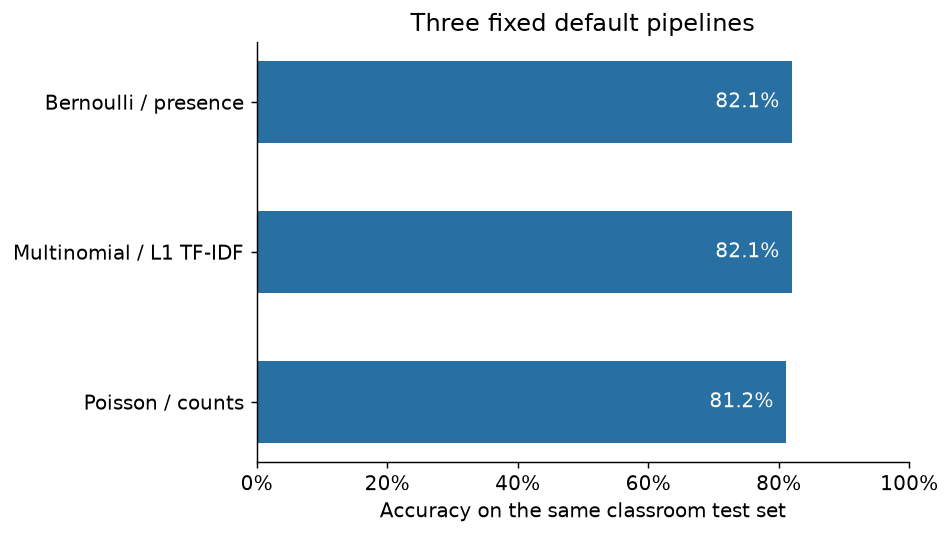

In [13]:
pnb = PoissonNB(alpha=DEFAULT_ALPHA).fit(count_train, train_y)
pred_pnb = pnb.predict(count_test)
pnb_acc = float(accuracy_score(test_y, pred_pnb))
np.testing.assert_allclose(pnb.predict_proba(count_test).sum(axis=1), 1)
summary = pd.DataFrame({
    "Pipeline": ["Bernoulli / presence", "Multinomial / L1 TF-IDF", "Poisson / counts"],
    "Vocabulary": [len(feature_names)]*3,
    "Alpha": [DEFAULT_ALPHA]*3,
    "Correct / 1000": [int((p == test_y).sum()) for p in [pred_bnb, pred_mnb, pred_pnb]],
    "Classroom test accuracy": [bnb_acc,mnb_acc,pnb_acc]
})
display(summary)
fig, ax = plt.subplots(figsize=(7.2, 4), layout="constrained")
bars = ax.barh(summary["Pipeline"], summary["Classroom test accuracy"], color=COLORS[0], height=.55)
ax.set(xlim=(0,1), xlabel="Accuracy on the same classroom test set", title="Three fixed default pipelines")
ax.xaxis.set_major_formatter(PercentFormatter(1));ax.invert_yaxis()
for bar,value in zip(bars,summary["Classroom test accuracy"]):
    ax.text(value-.02,bar.get_y()+bar.get_height()/2,f"{value:.1%}",va="center",ha="right",color="white")
show_figure(fig, "tutorial-models.png")

**怎样回答“适不适合”？** 先引用这次表里的表现，再回到假设：等曝光量Poisson把每篇文档的同一词计数当同一种试验，且要求给定类别后词计数独立；文档长短、词的共现与实际计数波动可能挑战这些假设。某次accuracy高或低都不能证明所有文档服从或不服从Poisson。

**English answer framework:** “Under the stated preprocessing, vocabulary and smoothing, the measured accuracy is … . This supports a comparison of these pipelines on this dataset. Equal document exposure and conditional count independence remain modeling assumptions; the score alone does not validate them.”

NB的高后验也不自动代表经过校准的真实可信度。对错误样本和每类表现的检查与总accuracy互补。

In [14]:
# Derived outputs only: no assignment submission files are generated.
results = {
    "purpose": "classroom exploration; the given test split is reused for comparison/tuning",
    "seed": SEED, "data_sha256": hashlib.sha256(AGNEWS_PATH.read_bytes()).hexdigest(),
    "train_n": len(train_y), "test_n": len(test_y), "actual_vocabulary": len(feature_names),
    "versions": versions,
    "default_accuracy": {"bernoulli": bnb_acc, "multinomial_tfidf": mnb_acc, "poisson_counts": pnb_acc},
    "bernoulli_parameter_experiments": bnb_parameter_table.to_dict(orient="records"),
    "alpha_experiment": alpha_table.to_dict(orient="records"),
    "vocabulary_experiment": vocab_table.to_dict(orient="records"),
    "confusion_mnb": cm.tolist(), "reviewed_error_indices": error_indices.tolist(),
    "class_counts": class_counts.to_dict(orient="records"),
    "checks": {"posterior_rows_sum_to_one": True, "poisson_matches_scipy": True,
               "zero_rate_guard": True, "non_integer_guard": True, "nonconsecutive_label_mapping": True}
}
(NOTE_DIR / "tutorial-results.json").write_text(json.dumps(results,ensure_ascii=False,indent=2)+"\n")

max_accuracy = float(summary["Classroom test accuracy"].max())
winners = summary.loc[np.isclose(summary["Classroom test accuracy"], max_accuracy), "Pipeline"].tolist()
alpha_ties = alpha_table.loc[np.isclose(alpha_table["Classroom test accuracy"],
                                       alpha_table["Classroom test accuracy"].max()), "alpha"].tolist()
disagreements = int((pred_bnb != pred_mnb).sum())
display(Markdown(
    "### 本次运行小结 / Executed result\n"
    f"默认设置下最高accuracy为 **{max_accuracy:.2%}**，达到这一值的流程是 **{' / '.join(winners)}**。"
    f"MNB/TF-IDF平滑网格中达到最高分的alpha为 **{alpha_ties}**；"
    f"MNB/TF-IDF独立词表实验的首个最好上限是 **{int(best_vocab_row['Requested limit'])}**。"
    f"Bernoulli与MNB在 **{disagreements}** 条记录上给出不同标签，总分相同也不代表预测相同。"
    "两组单变量实验没有联合优化；这份test已参与选择，不能当作最终独立成绩。\n\n"
    f"The highest fixed-default accuracy is **{max_accuracy:.2%}**, achieved by "
    f"**{' / '.join(winners)}**. Bernoulli and MNB disagree on {disagreements} records. "
    "These classroom comparisons do not establish universal superiority or an unbiased final score."
))


### 本次运行小结 / Executed result
默认设置下最高accuracy为 **82.10%**，达到这一值的流程是 **Bernoulli / presence / Multinomial / L1 TF-IDF**。MNB/TF-IDF平滑网格中达到最高分的alpha为 **[0.3, 1.0]**；MNB/TF-IDF独立词表实验的首个最好上限是 **5000**。Bernoulli与MNB在 **83** 条记录上给出不同标签，总分相同也不代表预测相同。两组单变量实验没有联合优化；这份test已参与选择，不能当作最终独立成绩。

The highest fixed-default accuracy is **82.10%**, achieved by **Bernoulli / presence / Multinomial / L1 TF-IDF**. Bernoulli and MNB disagree on 83 records. These classroom comparisons do not establish universal superiority or an unbiased final score.


## 9. 如果要严格评价泛化，流程怎样改？ / A separate evaluation protocol

**方法补充：** 若目标是评价选定流程的泛化能力，可采用以下设计：

1. 从给定train内部再划训练/验证，或做内层CV。
2. 每折分别拟合词表、IDF和模型；把这些步骤放在同一Pipeline中。
3. 在验证上选择表示、alpha和词表规模，固定方案后重拟合。
4. 最后才评估此前未参与开发的test。若本文件已经用test反复探索，不能事后把同一次分数改名为“独立测试”；需要新的未触碰数据或另一个预先明确的评估设计。

**English:** Tune on training-internal validation, refitting preprocessing inside each fold. Evaluate the fixed choice on untouched test data. Renaming an already explored test set does not restore its independence.

独立迁移题：某人在所有3000条新闻上先建词表，再只用2000条训练分类器。他说“模型没见过test标签，所以没泄漏”。哪里不对？  
English question: Someone fits a vocabulary on all 3000 documents but trains the classifier on only 2000. They claim there is no leakage because test labels were unused. What is wrong?  
答案：测试文本已经参与特征选择；无标签信息也会影响表示。验证目标若是对新数据泛化，预处理也必须只从对应训练部分学习。  
English answer: Test text influenced the representation. Leakage can involve unlabeled inputs; vocabulary learning must stay within the corresponding training split.


## 10. 回原课、练英文、再刷少量卡 / Return and recall

用英文解释三个问题，再去Markji按卡号巩固：
- Why must the vocabulary and IDF be fitted on training data?
- Why do Bernoulli, multinomial and Poisson smoothing have different denominators?
- Why is the highest score in these test-set sweeps not an unbiased final result?

对应中文：为何词表/IDF只从训练数据拟合？三个模型的平滑分母为何不同？为何这次扫test得到的最高分不是独立最终成绩？

最低合格要点 / Minimum answer points：
1. 中文：词表和IDF会学习输入分布，因此也必须留在训练部分。English: Vocabulary and IDF learn from input data and must be fitted within the training split.
2. 中文：Bernoulli对每词的两种结果平滑；Multinomial对词表中的V种结果平滑；这里Poisson的额外约定向总词次数和文档数分别加alpha。English: Bernoulli smooths two feature outcomes; multinomial smooths V token outcomes; the stated Poisson convention adds alpha to the total word count and document count.
3. 中文：test表现参与了模型和参数选择，已提供开发反馈。English: The test scores influenced model and parameter selection, so they are development feedback rather than an untouched final evaluation.


关联微课：[文本NB](https://crazyshout.github.io/micro-course/?lesson=ml08)、[Poisson NB](https://crazyshout.github.io/micro-course/?lesson=ml09)。
现有卡：[M078稀疏表示](https://crazyshout.github.io/micro-course/cards.html#CS5489-M078)、[M110调参比较](https://crazyshout.github.io/micro-course/cards.html#CS5489-M110)、[M112 Poisson率](https://crazyshout.github.io/micro-course/cards.html#CS5489-M112)、[M115平滑解释](https://crazyshout.github.io/micro-course/cards.html#CS5489-M115)。长实现仍需完整重做，不只背卡片输出。

### 原文件覆盖索引 / Source coverage
| 原cell | 本文件位置 |
|---|---|
| Tutorial2v2，第1–4个单元 | 开头、§0；Tutorial2v2，第1个单元为空白/导言，设置与路径 |
| Tutorial2v2，第5–9个单元 | §1 数据、规模、类别和文本 |
| Tutorial2v2，第10–12个单元 | §2 固定词表与矩阵 |
| Tutorial2v2，第13–16个单元 | §3 Bernoulli、前10词及alpha/词表的单因素比较 |
| Tutorial2v2，第17–20个单元 | §4 Multinomial TF-IDF与前10词 |
| Tutorial2v2，第21–24个单元 | §5 错分检查；填空题由解释框架和实测样本承接 |
| Tutorial2v2，第25–26个单元 | §6 alpha曲线 |
| Tutorial2v2，第27–28个单元 | §7 词表曲线 |
| Tutorial2v2，第29–32个单元 | §8.1–8.3 公式、约定、实现和手算检查 |
| Tutorial2v2，第33–35个单元 | §8.4 数据测试与模型讨论 |
| Tutorial2v2，第36个单元 | 空单元，无独立教学内容 |

参考原理以老师材料和[Lecture02](Lecture02.md)为主。库行为另核对[scikit-learn NB](https://scikit-learn.org/stable/modules/naive_bayes.html)、[TF-IDF参数](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html)。Poisson补充的Gamma后验均值沿用已核对的M115说明，不是模板定义的公式。